# Sensitivity analysis

A kinetic model like the one we'll use here can easily have 50-100 parameters. Some of them barely matter; others control the model's behaviour almost entirely. **Sensitivity analysis** answers the question "if I change this parameter a little, how much does the model's output change?" for every parameter at once, so we don't have to guess or test them one by one by hand.

This matters for a few practical reasons:
- **Model building**: it tells you which parameters are worth measuring carefully, and which ones you can leave at a rough estimate because the model barely responds to them anyway.
- **Biology**: parameters the system is very sensitive to are often the ones under the tightest control (or evolutionary pressure) in the real organism, since a small error there would be costly.
- **Robustness**: some outputs (e.g. a species concentration) may stay almost constant no matter which parameter you perturb — that tells you something about how the network is built, not just about the parameter.

The analysis we do here is a **local** sensitivity analysis: we look at small perturbations around one particular steady state, not the full range of possible parameter values. (A global analysis, e.g. by sampling many parameter combinations, is a different and complementary approach.)

In [1]:
from basico import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## Load the model

We'll use a detailed kinetic model of yeast glycolysis (`vanHeerden1.xml`).

In [2]:
model = load_model('models/vanHeerden1.xml')

Let's look at one specific reaction, `v1` (hexokinase, the first step of glycolysis), and its rate law.

In [3]:
get_reactions('v1', exact=True)

,scheme,flux,particle_flux,function,key,sbml_id,display_name,mapping
name,,,,,,,,
v1,GLCi + Prb = G6P,3.935193,2.369829e+24,Function for v1,Reaction_0,v1,(v1),"{'G6P': 'G6P', 'GLCi': 'GLCi', 'KEQAK': 'KEQAK..."


In [4]:
get_functions().loc['Function for v1'].formula

'VMAXHK*(GLCi*(-SUMAXP+(1-4*KEQAK)*Prb+(4*(1-4*KEQAK)*KEQAK*Prb^2+(SUMAXP-(1-4*KEQAK)*Prb)^2)^0.5)/(2*(1-4*KEQAK)*KMHKATP*KMHKGLCi)-G6P*(Prb-(-SUMAXP+(1-4*KEQAK)*Prb+(4*(1-4*KEQAK)*KEQAK*Prb^2+(SUMAXP-(1-4*KEQAK)*Prb)^2)^0.5)/(1-4*KEQAK))/(KEQHK*KMHKATP*KMHKGLCi))/(compartment*(1+G6P/KMHKG6P+wt*G6P/KiHKG6P+GLCi/KMHKGLCi)*(1+(-SUMAXP+(1-4*KEQAK)*Prb+(4*(1-4*KEQAK)*KEQAK*Prb^2+(SUMAXP-(1-4*KEQAK)*Prb)^2)^0.5)/(2*(1-4*KEQAK)*KMHKATP)+(Prb-(-SUMAXP+(1-4*KEQAK)*Prb+(4*(1-4*KEQAK)*KEQAK*Prb^2+(SUMAXP-(1-4*KEQAK)*Prb)^2)^0.5)/(1-4*KEQAK))/KMHKADP))/compartment'

This is a fairly complex rate law, reflecting years of enzymology research on this one enzyme, and it depends on many parameters (`KMHKGLCi`, `KMHKATP`, `KiHKG6P`, ...). Altogether, the model has close to 100 parameters. Which of them actually matter for the model's behaviour? We will asnwer this question with sensitivity analysis is built to answer.

## Setting up the sensitivity analysis

Before running the analysis, COPASI needs to know three things:
- the **effect**: the model output(s) we want to look at (e.g. steady-state concentrations, or reaction fluxes);
- the **cause**: the input(s) we vary (e.g. all parameter values, initial concentrations, or a single specific parameter);
- the **sub-task**: what kind of simulation to run for each perturbation (e.g. steady state, or a time course).

Let's check the default settings.

In [5]:
get_sensitivity_settings()

{'scheduled': False,
 'update_model': False,
 'method': {'Delta factor': 0.001,
  'Delta minimum': 1e-12,
  'name': 'Sensitivities Method'},
 'report': {'filename': '',
  'report_definition': 'Sensitivities',
  'append': True,
  'confirm_overwrite': True},
 'sub_task': 'Steady State',
 'effect': 'Non-Constant Concentrations of Species',
 'cause': 'All Parameter Values',
 'secondary_cause': 'Not Set'}

By default, COPASI will vary **all parameter values** (`cause`) one at a time, bring the model to **steady state** (`sub_task`) for each perturbed value, and record the effect on the **concentrations of all non-constant species** (`effect`). That's exactly what we want for a first, broad look at the model, so we'll keep these defaults.

## Run the sensitivity analysis

In [6]:
run_sensitivities()

The result can be read out in two forms:
- `get_unscaled_sensitivities()` gives the raw derivative $\dfrac{\partial(\text{effect})}{\partial(\text{cause})}$ for every effect/cause pair, in whatever units the effect and cause happen to have;
- `get_scaled_sensitivities()` normalises this by the parameter value and the species concentration:

$$\text{scaled sensitivity} = \frac{\partial(\text{effect})}{\partial(\text{cause})} \times \frac{\text{cause value}}{\text{effect value}}$$

A scaled sensitivity of, say, $-0.3$ means "a 1% increase in this parameter causes roughly a 0.3% *decrease* in this species' steady-state concentration". Because it's a relative (percentage-based) measure, scaled sensitivities can be directly compared across parameters and species with completely different units and magnitudes - which is why we'll work with the scaled version from here on.

In [7]:
sensitivities = get_scaled_sensitivities()
sensitivities.head()

,Values[CPFKAMP].InitialValue,Values[CPFKATP].InitialValue,Values[CPFKF16BP].InitialValue,Values[CPFKF26BP].InitialValue,Values[CPFKF6P].InitialValue,Values[CiPFKATP].InitialValue,Values[F26BP].InitialValue,Values[KATPASE].InitialValue,Values[KEQAK].InitialValue,Values[KEQHK].InitialValue,...,Values[VmPFK].InitialValue,Values[VmPGI].InitialValue,Values[VmPGK].InitialValue,Values[VmPGM].InitialValue,Values[VmPYK].InitialValue,Values[gR].InitialValue,Values[nPDC].InitialValue,Values[npyk].InitialValue,Values[pT].InitialValue,Values[wt].InitialValue
[ACE],-0.005177,-0.099602,-0.068432,-0.013759,0.0,-0.108841,0.073406,0.107650,0.004023,0.000011,...,0.098326,0.093840,-0.003157,-0.003237,-0.004458,0.107619,-1.148856e-12,-0.032654,-0.009874,-0.120252
[ATP],-0.008277,-0.159276,-0.109427,-0.022001,0.0,-0.174052,0.117367,-0.481590,0.018364,0.000005,...,0.157208,0.150036,0.004317,0.004426,0.006096,0.172064,5.385497e-13,0.044645,0.013502,-0.115855
[BPG],-0.033713,-0.648349,-0.445517,-0.089601,0.0,-0.708458,0.478238,-2.057048,0.006965,0.000020,...,0.640672,0.611430,-0.168019,-0.172272,-0.237244,0.701255,3.415688e-12,-1.737471,0.169225,-0.460078
[F16P],-0.022402,-0.430886,-0.296071,-0.059540,0.0,-0.470840,0.317745,-0.015335,0.014054,0.000040,...,0.425650,0.406225,-0.039385,-0.040382,-0.055611,0.465893,-1.407572e-12,-0.407240,-0.123178,-0.463933
[F6P],0.009878,0.190075,0.130586,0.026254,0.0,0.207708,-0.140056,-1.132183,0.016121,0.000046,...,-0.187598,0.688539,-0.003896,-0.003995,-0.005502,-0.205326,0.000000e+00,-0.040295,-0.012187,-0.657137


Rows are species, columns are parameters (named `Values[parameter_name].InitialValue`). Let's zoom in on one column: `KiHKG6P`, the inhibition constant for glucose-6-phosphate (G6P) acting back on hexokinase.

- A **negative** value means increasing this parameter *decreases* that species' steady-state concentration.
- A **positive** value means increasing this parameter *increases* it.
- The **larger the absolute value**, the bigger the effect.
- Values very close to zero mean essentially no effect. COPASI computes these sensitivities by numerical differentiation (perturbing each parameter by a small fraction), so values many orders of magnitude smaller than the rest (e.g. below $10^{-6}$ here) are just numerical noise, not a real effect.

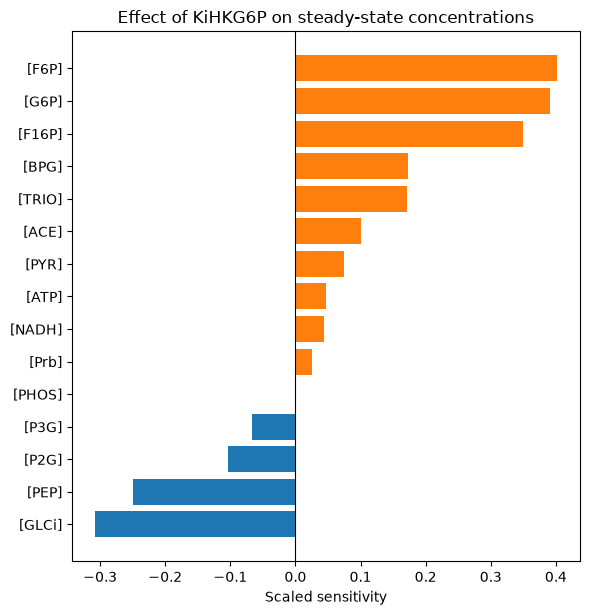

In [8]:
def clean_label(name):
    # turns 'Values[KiHKG6P].InitialValue' into the shorter 'KiHKG6P'
    match = re.match(r'Values\[(.*)\]\.InitialValue', str(name))
    return match.group(1) if match else str(name)


def plot_sensitivities(series, title, xlabel='Scaled sensitivity'):
    sorted_series = series.sort_values()
    labels = [clean_label(name) for name in sorted_series.index]
    colors = ['C0' if v < 0 else 'C1' for v in sorted_series]

    fig, ax = plt.subplots(figsize=(6, 0.35 * len(sorted_series) + 1))
    ax.barh(labels, sorted_series.values, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    fig.tight_layout()
    plt.show()

plot_sensitivities(sensitivities['Values[KiHKG6P].InitialValue'],
                    'Effect of KiHKG6P on steady-state concentrations')

`GLCi` (intracellular glucose) has the most negative sensitivity, and `F6P` (fructose-6-phosphate) the most positive. `PHOS` (inorganic phosphate) sits essentially at zero - its steady-state concentration barely responds to this particular parameter at all, even though `PHOS` is itself a variable, reaction-determined species in this model (it isn't just held fixed). Worth thinking about: can you see, from the reactions `PHOS` participates in, why it might be buffered against this particular perturbation while `GLCi` and `F6P` are not?

## Verify the results

A computed sensitivity is a prediction: "if you change this parameter, this is what should happen." Let's check that prediction directly, by actually changing `KiHKG6P` and re-computing the steady state for the most negative (`GLCi`), most positive (`F6P`), and near-zero (`PHOS`) cases identified above.

In [9]:
def steady_state_concentrations(param_name, param_value):
    set_parameters(param_name, initial_value=param_value)
    run_steadystate()
    return get_species()[['concentration']]


base_value = get_parameters().loc['KiHKG6P', 'initial_value']

conc_base = steady_state_concentrations('KiHKG6P', base_value)
conc_up = steady_state_concentrations('KiHKG6P', base_value * 1.10)   # +10%

# reset the model back to its original parameter value
set_parameters('KiHKG6P', initial_value=base_value)
run_steadystate()

check = pd.DataFrame({
    'steady state (base)': conc_base['concentration'],
    'steady state (+10% KiHKG6P)': conc_up['concentration'],
})
check['% change'] = 100 * (check['steady state (+10% KiHKG6P)'] - check['steady state (base)']) / check['steady state (base)']

# sensitivities are indexed as '[GLCi]', '[F6P]', ... -- strip the brackets so they
# align with check's plain species names ('GLCi', 'F6P', ...)
sens_col = sensitivities['Values[KiHKG6P].InitialValue'].copy()
sens_col.index = sens_col.index.str.strip('[]')

check['scaled sensitivity'] = sens_col
check['predicted % change (sensitivity x 10%)'] = check['scaled sensitivity'] * 10
check.loc[['GLCi', 'F6P', 'PHOS']]

,steady state (base),steady state (+10% KiHKG6P),% change,scaled sensitivity,predicted % change (sensitivity x 10%)
name,,,,,
GLCi,1.615186,1.56833,-2.900955e+00,-3.080277e-01,-3.080277e+00
F6P,0.232096,0.24104,3.853452e+00,4.015604e-01,4.015604e+00
PHOS,10.000000,10.00000,1.580958e-12,4.263256e-11,4.263256e-10


The `predicted % change` column (simply the scaled sensitivity scaled up from a 1% to a 10% change) lines up well with the `% change` we actually measured by simulating: both the sign and the rough size match for all three species, while `PHOS` barely moves either way. The small remaining mismatch between predicted and measured values is expected: sensitivities describe the *instantaneous* (infinitesimal) response, while here we made a finite 10% change.

## Summarized sensitivities

So far we've looked at one parameter's effect across many species. To instead find the parameters that matter most *overall* - pooling the effect across all species into one number per parameter - use `get_summarized_sensitivities()`. It computes, for each parameter, the 2-norm (square root of the sum of squares) of that parameter's column in the scaled sensitivity table:

$$\text{summarized sensitivity}_{\text{parameter}} = \sqrt{\sum_{\text{species}} \left(\text{scaled sensitivity}\right)^2}$$

Bigger values mean that parameter has a larger combined effect across the whole network.

In [10]:
summary = get_summarized_sensitivities()[0]  # the single column holds the summarized values
summary.sort_values(ascending=False).head(15)

Values[npyk].InitialValue          4.420926
Values[VmGAPDHf].InitialValue      3.227184
Values[KmGAPDHGAP].InitialValue    2.800116
Values[KATPASE].InitialValue       2.543436
Values[SUMAXP].InitialValue        2.500541
Values[VmGLT].InitialValue         1.857367
Values[VMAXHK].InitialValue        1.614640
Values[KeqTPI].InitialValue        1.609868
Values[KmPYKPEP].InitialValue      1.427576
Values[KmPYKF16P].InitialValue     1.383596
Values[KeqALD].InitialValue        1.327793
Values[wt].InitialValue            1.221042
Values[VmENO].InitialValue         1.174244
Values[VmPGI].InitialValue         1.092170
Values[pT].InitialValue            1.046720
Name: 0, dtype: float64

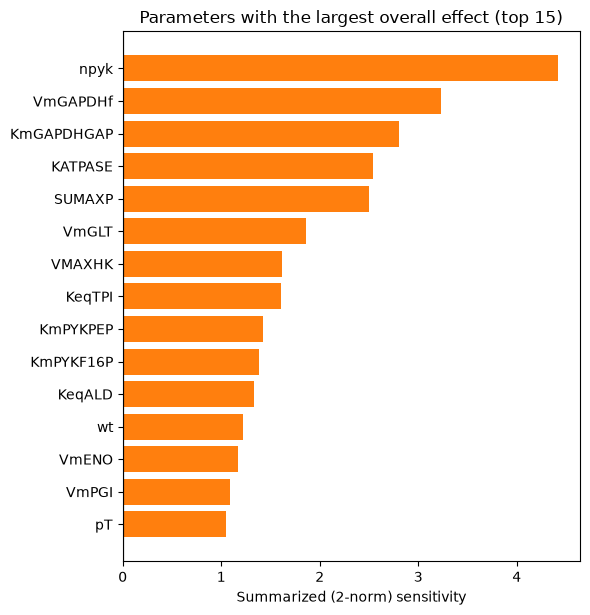

In [11]:
top15 = summary.sort_values(ascending=False).head(15)
plot_sensitivities(top15.sort_values(), 'Parameters with the largest overall effect (top 15)',
                    xlabel='Summarized (2-norm) sensitivity')

These are the parameters the model as a whole is most sensitive to. In a real research setting, this list is useful in (at least) two ways: it tells you which parameters are worth measuring most precisely if you want a trustworthy model, and — since a parameter the system depends on strongly is also one where errors are most costly to the organism — it can point to which enzymes might be under the tightest regulatory or evolutionary control.

## Which species are the most robust?

We can flip the same idea around. Instead of summarizing each *column* (one number per parameter, pooling across species), we can summarize each *row* (one number per species, pooling across all ~100 parameters) using the same 2-norm formula. This tells us which species barely move regardless of which parameter is perturbed — i.e. which concentrations are the most robustly maintained by the network — versus which ones are the most fragile.

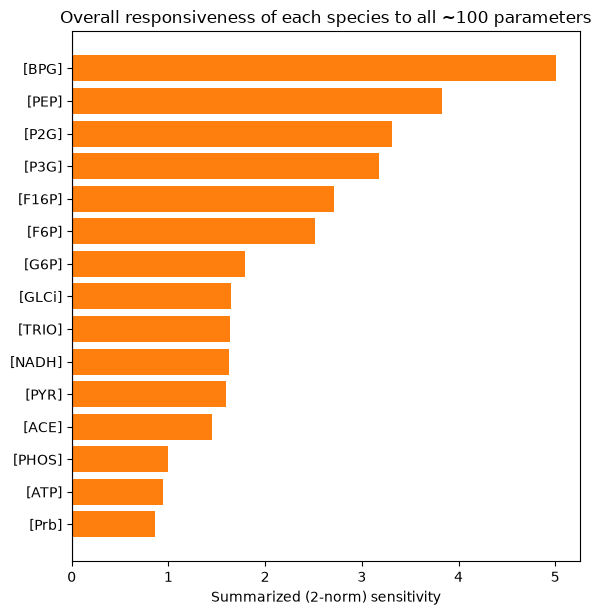

In [12]:
species_robustness = np.sqrt((sensitivities ** 2).sum(axis=1)).sort_values()
plot_sensitivities(species_robustness, 'Overall responsiveness of each species to all ~100 parameters',
                    xlabel='Summarized (2-norm) sensitivity')

`Prb` (the adenine nucleotide pool proxy used in this model) and `ATP` come out as the most robust, essentially unmoved by most individual parameter changes — consistent with the idea that cells tightly maintain their adenine nucleotide (ATP/ADP/AMP) pool, since so many processes depend on it. `BPG` (1,3-bisphosphoglycerate), by contrast, is the most fragile: a low-abundance, highly reactive intermediate that responds strongly to almost any parameter change nearby in the pathway.

## Summary and exercises

Sensitivity analysis turns "which of these ~100 parameters actually matter?" from a guess into a computable, checkable answer — and it can be read in different ways depending on the question: one parameter's effect across all species, one species' sensitivity to all parameters, or a single combined ranking of either.

1. Pick a different single parameter (e.g. one of the top 5 from the summarized sensitivities above) and repeat the "verify the results" step: perturb it directly and check that the direction and rough size of the change match the predicted sensitivities.
2. `effect` doesn't have to be species concentrations. Try changing it to reaction fluxes and rerun the analysis — this connects directly to **metabolic control analysis (MCA)** and its flux control coefficients:
   ```python
   settings = get_sensitivity_settings()
   settings['effect'] = 'Concentration Fluxes of Reactions'
   set_sensitivity_settings(settings)
   run_sensitivities()
   get_scaled_sensitivities()
   ```
   Which parameters have the most control over flux through the pathway? Are they the same ones that control species concentrations most strongly?
3. `cause` can also be restricted to a single parameter (`'Single Object'`) or to initial concentrations instead of parameter values. Try setting up an analysis where the cause is the initial concentration of `GLCi` instead — how does the network respond to different starting glucose levels?
4. The default `sub_task` is `'Steady State'`. Try `'Time Series'` instead (you'll also need to make sure a time course duration is set) to see how sensitivities can change over the course of a simulation, rather than only at steady state.